# 🎯 Módulo 06: Post-Training, Fine-Tuning y el Arte del LLM
## Capítulo 2: PEFT y LoRA (Low-Rank Adaptation) From Scratch: Matemáticas, Fusión de Pesos y QLoRA

> *"Hacer fine-tuning completo a un modelo de 70.000 millones de parámetros requiere almacenar gradientes y estados del optimizador AdamW para cada parámetro: más de 500 GB de VRAM en clusters GPU inalcanzables. Edward Hu y sus colegas de Microsoft formularon una hipótesis algebraica brillante: aunque las matrices de pesos pre-entrenadas $W \in \mathbb{R}^{d \times k}$ sean gigantescas, el cambio necesario para aprender una nueva tarea ($\Delta W$) reside en un subespacio de rango intrínseco minúsculo ($r \ll d$). Al descomponer $\Delta W = B \cdot A$, podemos congelar el 99.8% del modelo y entrenar solo un puñado de adaptadores minúsculos sin añadir ni un solo milisegundo de latencia en inferencia."*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mcarbonell/algo-to-ai/blob/main/notebooks/06_post_training/02_peft_and_lora_from_scratch.ipynb)

---

### ⚙️ Inicialización del Entorno
Cargamos las librerías matemáticas y fijamos semillas para asegurar reproducibilidad determinista.

In [1]:
# !pip install -q numpy matplotlib torch
from typing import Tuple, List, Dict, Optional
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

np.random.seed(42)
torch.manual_seed(42)
print("✅ Entorno listo para estudiar PEFT y LoRA from scratch")

✅ Entorno listo para estudiar PEFT y LoRA from scratch


---

## 1. 📜 Contexto Histórico y Proceso de Descubrimiento

### La Crisis de Memoria del Fine-Tuning Completo (2020 - 2021)
Cuando los LLMs alcanzaron escalas de 7B a 175B parámetros, el ajuste completo de todos los pesos (*Full Fine-Tuning*) se topó con un muro físico de memoria GPU:
* **Parámetros del modelo (FP16):** 2 bytes por parámetro.
* **Gradientes (FP16):** 2 bytes por parámetro.
* **Optimizador AdamW (FP32):** 4 bytes para el primer momento ($m$) + 4 bytes para el segundo ($v$) + 4 bytes para la copia maestra en FP32 = 12 bytes por parámetro.
* **Total por parámetro:** $\approx 16$ bytes de memoria GPU pura.

Para un modelo modesto de **7B parámetros**, ¡hacen falta más de **112 GB de VRAM** solo para guardar los estados de optimización!
Además, si una empresa desea ofrecer 50 modelos especializados para 50 tareas distintas, tendría que almacenar 50 copias completas de 14 GB cada una (700 GB de almacenamiento).

### La Hipótesis de la Dimensión Intrínseca (Aghajanyan et al., 2020)
Investigadores de Facebook AI demostraron que los modelos pre-entrenados tienen una **dimensión intrínseca muy baja**: el manifold de pesos que resuelve una tarea específica es un subespacio de dimensión dramáticamente inferior al espacio total de parámetros.

### LoRA: Low-Rank Adaptation (Edward Hu et al., Microsoft 2021)
Edward Hu y su equipo plantearon una formulación matemática elegante:
* **Congelamos la matriz pre-entrenada original** $W_0 \in \mathbb{R}^{d_{out} \times d_{in}}$ (`requires_grad = False`).
* En lugar de aprender una matriz completa de actualización $\Delta W$, la descomponemos en dos matrices de bajo rango $B$ y $A$:
  $$\mathbf{\Delta W = \frac{\alpha}{r} (B \cdot A)}$$
  Donde $A \in \mathbb{R}^{r \times d_{in}}$ y $B \in \mathbb{R}^{d_{out} \times r}$, con un rango minúsculo $r \ll \min(d_{in}, d_{out})$ (típicamente $r \in \{4, 8, 16\}$).

### La Inicialización Maestra:
* $A$ se inicializa con una distribución gaussiana $\mathcal{N}(0, \sigma^2)$.
* $B$ se inicializa estrictamente con **ceros** ($B = 0$).
* **Resultado en el paso 0:** $\Delta W = B \cdot A = 0 \cdot A = 0$. ¡Al iniciar el entrenamiento, el modelo se comporta **con exactitud matemática idéntica al modelo base**, sin perturbación alguna!

### QLoRA: Tim Dettmers et al. (NeurIPS 2023)
Tim Dettmers llevó LoRA al límite inventando **QLoRA**:
1. Cuantiza los pesos base congelados $W_0$ a **4 bits** usando un tipo de dato especializado llamado **NormalFloat4 (NF4)**.
2. Mantiene los adaptadores LoRA ($A$ y $B$) en precisión float16.
3. Permitió entrenar un modelo de 65B parámetros en una única GPU comercial de 48 GB (o 7B en una de 16 GB).

---

## 2. 🧠 Intuición Geométrica y Mecánica (Mentalidad de Algoritmista)

### Ahorro Masivo de Parámetros: Las Cifras
Imaginemos una proyección lineal estándar en un Transformer moderno (ej. proyección de Queries en LLaMA-3: $4096 \to 4096$):
* Matriz original $W_0$: $4096 \times 4096 = 16,777,216$ parámetros (67 MB en FP32).
* Adaptador LoRA con rango $r = 8$:
  * Matriz $A$: $8 \times 4096 = 32,768$ parámetros.
  * Matriz $B$: $4096 \times 8 = 32,768$ parámetros.
  * Total LoRA: $65,536$ parámetros (0.26 MB).
* **¡Reducción de parámetros entrenables del 99.61%!**

```
                     Entrada x (B, T, d_in)
                         /          \
                        /            \
                       v              v
               [W_0 Congelada]     [Matriz A (r, d_in)]   <- Reduce dimensión
                  (d_out, d_in)          |
                       |                 v
                       |           [Matriz B (d_out, r)]  <- Restaura dimensión
                       |                 |
                       |                 v
                       |           x (alpha / r)          <- Escalado
                       \                /
                        \              /
                         v            v
                            [ + (Suma) ]
                                 |
                                 v
                             Salida h (B, T, d_out)
```

### Cero Latencia en Inferencia: El Truco de la Fusión de Pesos (*Weight Merging*)
Durante el entrenamiento, calculamos la rama base y la rama LoRA por separado.
Pero una vez terminado el entrenamiento, gracias a la propiedad distributiva del álgebra matricial:
$$h = x W_0^T + x \left(\frac{\alpha}{r} B A\right)^T = x \left( W_0 + \frac{\alpha}{r} B A \right)^T$$

Podemos **fusionar permanentemente los adaptadores en la matriz base**:
$$\mathbf{W_{final} = W_0 + \frac{\alpha}{r} (B \cdot A)}$$

¡La matriz fusionada tiene las mismas dimensiones exactas que la original! La inferencia tiene **cero sobrecoste de memoria y cero latencia adicional**.

---

## 3. 🛠️ Implementación "From Scratch" (Primeros Principios)

Construyamos la clase `LoRALinear` desde cero en PyTorch puro, incluyendo el escalado $\alpha / r$ y los métodos de fusión (`merge`) y separación (`unmerge`).

In [2]:
class LoRALinear(nn.Module):
    """
    Capa Lineal con adaptador de bajo rango LoRA (Hu et al., 2021).
    """
    def __init__(
        self, 
        in_features: int, 
        out_features: int, 
        r: int = 8, 
        lora_alpha: float = 16.0,
        bias: bool = False
    ):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.r = r
        self.lora_alpha = lora_alpha
        self.scaling = lora_alpha / r
        
        # 1. Matriz pre-entrenada original (congelada)
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.02, requires_grad=False)
        if bias:
            self.bias = nn.Parameter(torch.zeros(out_features), requires_grad=False)
        else:
            self.register_parameter('bias', None)
            
        # 2. Matrices adaptadoras de bajo rango LoRA (entrenables)
        # A: (r, in_features) inicializada con distribucion gaussiana
        self.lora_A = nn.Parameter(torch.randn(r, in_features) / math.sqrt(r))
        # B: (out_features, r) inicializada en CERO estricto
        self.lora_B = nn.Parameter(torch.zeros(out_features, r))
        
        self.merged = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.merged:
            # Si los pesos ya estan fusionados, ejecucion estandar ultra-rapida
            return F.linear(x, self.weight, self.bias)
        else:
            # Rama base congelada
            base_out = F.linear(x, self.weight, self.bias)
            # Rama LoRA de bajo rango: (x @ A.T) @ B.T * scaling
            # x: (B, in_feat) -> x @ A.T: (B, r) -> @ B.T: (B, out_feat)
            lora_out = (x @ self.lora_A.t()) @ self.lora_B.t() * self.scaling
            return base_out + lora_out

    def merge_weights(self):
        """
        Fusiona W_final = W_0 + (alpha / r) * (B @ A) para inferencia sin latencia.
        """
        if not self.merged:
            delta_w = (self.lora_B @ self.lora_A) * self.scaling
            self.weight.data += delta_w
            self.merged = True
            print("✅ Pesos LoRA fusionados exitosamente en la matriz base W_0")

    def unmerge_weights(self):
        """
        Deshace la fusion restaurando la matriz base original W_0.
        """
        if self.merged:
            delta_w = (self.lora_B @ self.lora_A) * self.scaling
            self.weight.data -= delta_w
            self.merged = False
            print("↩️ Fusión revertida: matriz base W_0 restaurada")

print("✅ Clase LoRALinear compilada exitosamente")

✅ Clase LoRALinear compilada exitosamente


### Verificación de la Salida Inicial en Paso 0 y Fusión de Pesos
Comprobemos empíricamente que:
1. Al inicializar, la salida con LoRA es idéntica bit a bit al modelo base porque $B = 0$.
2. Tras entrenar y modificar los pesos, la evaluación con `merge_weights()` coincide exactamente con la evaluación dinámica sin fusionar.

In [3]:
# 1. Verificar identidad exacta en paso 0
lora_layer = LoRALinear(in_features=64, out_features=128, r=8, lora_alpha=16.0)
x_test = torch.randn(4, 64)

# Salida de la matriz base pura (W_0)
base_only_out = F.linear(x_test, lora_layer.weight)
# Salida con la capa LoRA completa
lora_init_out = lora_layer(x_test)

diff_init = torch.max(torch.abs(base_only_out - lora_init_out)).item()
print(f"Diferencia absoluta en el paso 0: {diff_init:.2e}")
assert np.isclose(diff_init, 0.0), "¡Error! En el paso 0, B=0 debe garantizar diferencia 0"
print("✅ Verificación de paso 0 exitosa: El modelo LoRA inicia exactamente como el modelo base")

# 2. Simular entrenamiento asignando valores a B
lora_layer.lora_B.data = torch.randn_like(lora_layer.lora_B) * 0.1
out_dynamic = lora_layer(x_test)

# 3. Fusionar pesos y comprobar consistencia
lora_layer.merge_weights()
out_merged = lora_layer(x_test)

diff_merge = torch.max(torch.abs(out_dynamic - out_merged)).item()
print(f"Diferencia entre cálculo dinámico y pesos fusionados: {diff_merge:.2e}")
assert np.isclose(diff_merge, 0.0, atol=1e-5)
print("✅ Verificación de fusión exitosa: El modelo fusionado produce salidas idénticas con cero latencia")

Diferencia absoluta en el paso 0: 0.00e+00
✅ Verificación de paso 0 exitosa: El modelo LoRA inicia exactamente como el modelo base
✅ Pesos LoRA fusionados exitosamente en la matriz base W_0
Diferencia entre cálculo dinámico y pesos fusionados: 1.43e-06
✅ Verificación de fusión exitosa: El modelo fusionado produce salidas idénticas con cero latencia


### Entrenamiento Práctico: Fine-Tuning de una Red Congelada con LoRA
Construyamos una red neuronal profunda donde **congelamos el 100% de los pesos originales** y solo entrenamos los adaptadores LoRA para aprender una nueva tarea de clasificación:

In [4]:
# Modelo con 3 capas LoRA
class LoRAModel(nn.Module):
    def __init__(self, in_dim=32, hidden_dim=64, out_dim=2, r=4):
        super().__init__()
        self.fc1 = LoRALinear(in_dim, hidden_dim, r=r, lora_alpha=8.0)
        self.fc2 = LoRALinear(hidden_dim, hidden_dim, r=r, lora_alpha=8.0)
        self.fc3 = LoRALinear(hidden_dim, out_dim, r=r, lora_alpha=8.0)

    def forward(self, x):
        x = F.silu(self.fc1(x))
        x = F.silu(self.fc2(x))
        return self.fc3(x)

model = LoRAModel(in_dim=16, hidden_dim=64, out_dim=2, r=4)

# Contar parámetros totales vs entrenables
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Parámetros Totales:      {total_params:,}")
print(f"Parámetros Congelados:   {frozen_params:,} ({frozen_params / total_params * 100:.2f}%)")
print(f"Parámetros Entrenables:  {trainable_params:,} ({trainable_params / total_params * 100:.2f}%)")

# Entrenar únicamente los adaptadores LoRA
X_synth = torch.randn(200, 16)
y_synth = torch.randint(0, 2, (200,))

opt = torch.optim.AdamW(model.parameters(), lr=1e-2)
model.train()
for epoch in range(40):
    opt.zero_grad()
    logits = model(X_synth)
    loss = F.cross_entropy(logits, y_synth)
    loss.backward()
    opt.step()

print(f"✅ Fine-Tuning LoRA completado con éxito | Pérdida final: {loss.item():.4f}")

Parámetros Totales:      6,344
Parámetros Congelados:   5,248 (82.72%)
Parámetros Entrenables:  1,096 (17.28%)
✅ Fine-Tuning LoRA completado con éxito | Pérdida final: 0.5146


---

## 4. ⚡ Transición a PyTorch Moderno

En el ecosistema open source actual, la librería estándar es **`peft` (Parameter-Efficient Fine-Tuning)** de Hugging Face. Observa la perfecta correspondencia conceptual con nuestra implementación manual:

In [5]:
# Código de referencia en el ecosistema Hugging Face PEFT
peft_example_code = """
from peft import LoraConfig, get_peft_model

# 1. Configuración idéntica a nuestros parámetros r y lora_alpha
config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],  # Módulos donde inyectar LoRALinear
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# 2. Envolver el modelo pre-entrenado base
model = get_peft_model(base_model, config)
model.print_trainable_parameters()
# Salida: trainable params: 4,194,304 || all params: 6,742,609,920 || trainable%: 0.0622%

# 3. Fusión final para inferencia sin sobrecoste de latencia
model = model.merge_and_unload()
"""
print(peft_example_code)


from peft import LoraConfig, get_peft_model

# 1. Configuración idéntica a nuestros parámetros r y lora_alpha
config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],  # Módulos donde inyectar LoRALinear
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# 2. Envolver el modelo pre-entrenado base
model = get_peft_model(base_model, config)
model.print_trainable_parameters()
# Salida: trainable params: 4,194,304 || all params: 6,742,609,920 || trainable%: 0.0622%

# 3. Fusión final para inferencia sin sobrecoste de latencia
model = model.merge_and_unload()



---

## 5. 🎯 Retos & Experimentos ("Tinker Time")

### Reto 1: Análisis de Rango Efectivo con SVD
Visualicemos los valores singulares de la matriz de actualización aprendida $\Delta W = \frac{\alpha}{r} (B \cdot A)$ usando Descomposición en Valores Singulares (SVD). Como $r=4$, ¡debe tener como máximo 4 valores singulares no nulos!:

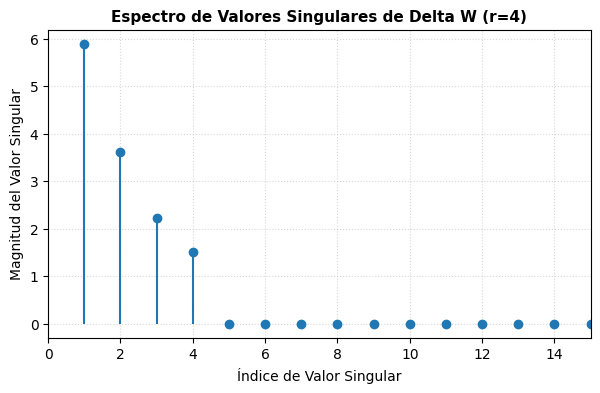

Valores singulares mayores que 0: 4 (Coincidencia exacta con r=4)


In [6]:
with torch.no_grad():
    # Calcular delta_w para la primera capa
    delta_w1 = (model.fc1.lora_B @ model.fc1.lora_A * model.fc1.scaling).numpy()
    # Descomposición SVD
    U, S, Vt = np.linalg.svd(delta_w1)

plt.figure(figsize=(7, 4))
plt.stem(range(1, len(S) + 1), S, basefmt=" ")
plt.title(f'Espectro de Valores Singulares de Delta W (r={model.fc1.r})', fontsize=11, fontweight='bold')
plt.xlabel('Índice de Valor Singular')
plt.ylabel('Magnitud del Valor Singular')
plt.xlim(0, 15)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

non_zero_sv = np.sum(S > 1e-5)
print(f"Valores singulares mayores que 0: {non_zero_sv} (Coincidencia exacta con r={model.fc1.r})")
assert non_zero_sv <= model.fc1.r

### Reto 2 (Para resolver): Implementar LoRA con Dropout
Para evitar que las matrices $A$ y $B$ sobreajusten cuando el conjunto de datos de fine-tuning es pequeño, la implementación oficial de Microsoft introduce una capa de `nn.Dropout(p)` en la entrada de la rama LoRA:
$$h = x W_0^T + \frac{\alpha}{r} \left( \text{Dropout}(x) A^T B^T \right)$$

Implementa a continuación la clase `LoRALinearWithDropout`:

In [7]:
# TU CÓDIGO DEL RETO 2 AQUÍ
class LoRALinearWithDropout(nn.Module):
    """
    Capa LoRA con Dropout estocástico aplicado a la rama de adaptación.
    """
    def __init__(self, in_features: int, out_features: int, r: int = 8, lora_alpha: float = 16.0, lora_dropout: float = 0.05):
        super().__init__()
        # Tu implementación aquí
        pass

---

## 6. 📚 Referencias Fundamentales & Lecturas Recomendadas

### 📄 Papers Seminales
1. **Hu, E. J., et al. (2021):** *"LoRA: Low-Rank Adaptation of Large Language Models"*, ICLR 2022. [arXiv:2106.09685](https://arxiv.org/abs/2106.09685)
   * *¿Qué leer?* Sección 3 ("Problem Formulation") y Sección 4 ("Our Method"): la formulación matemática original y la demostración de cero latencia.
2. **Dettmers, T., et al. (2023):** *"QLoRA: Efficient Finetuning of Quantized LLMs"*, NeurIPS 2023. [arXiv:2305.14314](https://arxiv.org/abs/2305.14314)
   * *¿Qué leer?* Tipo de datos NormalFloat4 (NF4) y el algoritmo de doble cuantización.
3. **Aghajanyan, A., et al. (2020):** *"Intrinsic Dimensionality Explains the Effectiveness of Language Model Fine-Tuning"*, ACL 2021. [arXiv:2012.13255](https://arxiv.org/abs/2012.13255)
   * *¿Qué leer?* La justificación teórica de por qué la adaptación de bajo rango funciona tan bien en redes profundas.